# TP3 Recuperatorio Grupal

**Modalidad:** grupos de 4 a 5 integrantes.

**Entrega:** notebook completo y ejecutable + corpus en `csv` o `jsonl`.

**Principio de trabajo:** un modelo puede acelerar tareas, pero no reemplaza una buena pregunta, un corpus bien construido ni el criterio humano. En analisis textual sigue valiendo la regla `garbage in, garbage out`.

## Introducción: El sentido del Análisis Computacional de Textos

Antes de ejecutar la primera línea de código, es fundamental comprender qué estamos buscando cuando aplicamos técnicas de Procesamiento de Lenguaje Natural (PLN) en las humanidades digitales y las ciencias sociales computacionales. Los algoritmos no "leen" ni "comprenden" los textos, sino que rastrean y cuantifican patrones lingüísticos. Nuestro trabajo como investigadores no es cederle la interpretación a la máquina, sino usar la computadora como una lente de aumento para volver visibles patrones discursivos.

Para que este enfoque funcione, hay tres dimensiones teórico-prácticas que debemos tener en cuenta:

### 1. El diseño del corpus: "Comparar lo comparable"

El paso analítico más importante no ocurre en el código, sino en la selección del corpus. Si comparamos textos que son inherentemente distintos, por ejemplo una novela romántica contra un manual de física, el algoritmo simplemente nos confirmará lo obvio. El verdadero poder del análisis computacional emerge cuando trabajamos sobre grandes volúmenes de textos que, en principio, parecen idénticos, comparten el mismo género, tratan sobre el mismo tema, ocurren en la misma fecha, pero difieren en una dimensión sutil, como su posición ideológica o su encuadre periodístico. El algoritmo nos permite medir matemáticamente cómo dos discursos construyen mundos diferentes a partir del mismo suceso.

### 2. La trampa del "Garbage In, Garbage Out"

Los modelos de PLN son literales. Si el corpus ingresa sucio, los resultados serán ruido. Un texto natural está lleno de "palabras vacías" (artículos, preposiciones) y verbos genéricos (ser, estar, hacer) que estadísticamente aplastan al vocabulario significativo. Del mismo modo, géneros como el periodismo incluyen vocabulario muy general del género ("nota", "gobierno", "ley") que no aporta valor analítico. El preprocesamiento de los datos, la eliminación de stopwords, la corrección de lemas, la limpieza de ruido estructural, no es una tarea técnica o automática; es una intervención interpretativa y humana crítica sin la cual el análisis resulta inútil.

### 3. Distinción algorítmica: De la frecuencia absoluta a la especificidad (TF-IDF)

Contar qué palabras se repiten más a menudo (frecuencia bruta) rara vez es revelador en grandes volúmenes de texto. La clave del análisis a escala está en encontrar el vocabulario distintivo. Técnicas estadísticas como el TF-IDF penalizan las palabras que todos usan por igual y exaltan aquellas que son exclusivas de un corpus frente a otro. Junto con el análisis de bigramas, pares de palabras que capturan locuciones o conceptos completos, estas métricas no reemplazan la lectura cualitativa: la potencian. Nos indican dónde mirar y qué palabras están funcionando como anclas ideológicas, para que luego nosotros, mediante una lectura atenta, podamos explicar el por qué.

## Que tienen que entregar

- este notebook completo y ejecutable;
- un corpus con **12 textos**: **6 por medio**;
- un mismo tema en ambos medios;
- la columna `grupo_comparacion` con exactamente dos valores posibles;
- una comparacion entre stopwords de `spaCy` y `NLTK`;
- al menos **dos ajustes humanos** del pipeline: uno lexico y uno estructural;
- una comparacion entre `Bag of Words` y `TF-IDF`;
- una lectura de bigramas;
- al menos dos visualizaciones analiticas legibles;
- una vuelta a fragmentos concretos del corpus;
- una conclusion interpretativa y metodologica.

## Que es un corpus

Un corpus no es una pila de textos. Un corpus es una coleccion **finita, explicita, comparable y documentada** de textos seleccionados para responder una pregunta.

Para este trabajo importa especialmente que el corpus:

- responda a una pregunta clara;
- use un criterio de inclusion visible;
- permita una comparacion defendible entre dos grupos;
- conserve trazabilidad de origen;
- haga visibles sus limites.

## Columnas minimas del corpus

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `url`
- `texto`
- `grupo_comparacion`

En la mayoria de los casos `grupo_comparacion` va a coincidir con los nombres de los dos medios elegidos.

In [1]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Elegimos un estilo simple y legible para todos los graficos.
sns.set_theme(style="ticks", context="notebook", palette="colorblind")

# Ampliamos el ancho visible de las columnas textuales.
pd.set_option("display.max_colwidth", 160)

print("Entorno cargado.")

Entorno cargado.


## 0. Configuracion

Guarden el corpus en la misma carpeta que este notebook. Si usan otro nombre o formato, cambien las variables de esta celda.

In [2]:
RUTA_CORPUS = Path("corpus_tp3.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_md"
TOP_N = 12
VENTANA_FRAGMENTO = 160

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Modelo spaCy esperado: {MODELO_SPACY}")

Ruta esperada del corpus: corpus_tp3.csv
Modelo spaCy esperado: es_core_news_md


## 1. Decisiones metodologicas

Agreguen una celda Markdown nueva y respondan, de manera breve, estas cuatro preguntas:

1. Que comparan exactamente.
2. Por que eligieron estos 12 textos y no otros.
3. Que vuelve comparables a ambos medios.
4. Que sesgos o limites iniciales ven en el corpus.

## 2. Carga y validacion del corpus

Vamos a trabajar en pasos separados. La idea es que se vea con claridad que valida cada bloque.

In [3]:
COLUMNAS_REQUERIDAS = [
    "id",
    "fecha",
    "medio",
    "autor",
    "titulo",
    "url",
    COLUMNA_TEXTO,
    COLUMNA_GRUPO,
]

# Primero revisamos si el archivo existe.
archivo_existe = RUTA_CORPUS.exists()

if not archivo_existe:
    raise FileNotFoundError(
        f"No se encontro {RUTA_CORPUS}. Guardalo en esta carpeta o corregi RUTA_CORPUS."
    )

# Despues revisamos si el formato declarado es valido.
formatos_validos = ["csv", "jsonl"]

if FORMATO_CORPUS not in formatos_validos:
    raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")

print("Archivo encontrado y formato declarado correctamente.")

Archivo encontrado y formato declarado correctamente.


In [4]:
# Esta celda solo carga el archivo. Todavia no valida su contenido.
if FORMATO_CORPUS == "csv":
    df = pd.read_csv(RUTA_CORPUS, sep=None, engine='python')
else:
    df = pd.read_json(RUTA_CORPUS, lines=True)

print(f"Archivo cargado: {len(df)} filas.")

Archivo cargado: 12 filas.


In [5]:
# Miramos una muestra del corpus tal como llego del archivo.
display(df.head())

,﻿id,fecha,medio,autor,titulo,texto,grupo_comparacion,url
0,1,22/4/2026,mit technology review,MIT Technology Review Insights,La IA necesita un sólido tejido de datos para aportar valor empresarial,"La inteligencia artificial avanza rápidamente en el ámbito empresarial, pasando de la experimentación al uso cotidiano. Las organizaciones están desplegando...",mit,https://technologyreview.es/article/la-ia-necesita-un-solido-tejido-de-datos-para-aportar-valor-empresarial
1,2,13/4/2026,mit technology review,Will Douglas Heaven,Por qué nuestra opinión sobre la IA está tan dividida,"En una industria que no se detiene, el AI Index de Stanford, un compendio anual de resultados y tendencias clave, es una oportunidad para tomar perspectiva....",mit,https://technologyreview.es/article/por-que-la-opinion-sobre-la-ia-esta-tan-dividida
2,3,20/3/2026,mit technology review,Will Douglas Heaven,OpenAI está volcando todos sus esfuerzos en desarrollar un investigador completamente automatizado,OpenAI está reorientando sus esfuerzos de investigación y volcando sus recursos en un nuevo gran desafío. La firma de San Francisco se ha fijado el objetivo...,mit,https://technologyreview.es/article/openai-esta-volcando-todos-sus-esfuerzos-en-desarrollar-un-investigador-completamente-automatizado
3,4,10/3/2026,mit technology review,Will Douglas Heaven,Cómo Pokémon Go dota a los robots de reparto de una visión del mundo de precisión milimétrica,"Pokémon Go fue el primer gran éxito mundial de realidad aumentada. Lanzado en 2016 por Niantic, una empresa escindida de Google, el giro de RA en la mastodó...",mit,https://technologyreview.es/article/como-pokemon-go-dota-a-los-robots-de-reparto-de-una-vision-del-mundo-de-precision-milimetrica
4,5,13/2/2026,mit technology review,Redacción,Los 14 términos de IA que marcaron 2025,"1. Superinteligencia\nDesde que la gente empezó a entusiasmarse con la IA, ha ido proponiendo nombres para una forma futura y ultrapotente de esta tecnologí...",mit,https://technologyreview.es/article/104013


In [6]:
# Elimina espacios en blanco y caracteres ocultos (BOM) de los nombres de las columnas
df.columns = df.columns.str.strip().str.replace('﻿', '') # El segundo es el caracter BOM oculto

# Opcional: Si quieres que no importe mayúsculas/minúsculas, puedes pasarlas todas a minúsculas:
# df.columns = df.columns.str.lower()

In [7]:
#Comprobamos que los nombres de las columnas sean correctos y no tengan caracteres ocultos.
print(df.columns.tolist())
print([repr(col) for col in df.columns])

['id', 'fecha', 'medio', 'autor', 'titulo', 'texto', 'grupo_comparacion', 'url']
["'id'", "'fecha'", "'medio'", "'autor'", "'titulo'", "'texto'", "'grupo_comparacion'", "'url'"]


In [15]:
# Ahora revisamos si estan todas las columnas obligatorias.
faltantes = []

for columna in COLUMNAS_REQUERIDAS:
    if columna not in df.columns:
        faltantes.append(columna)

if faltantes:
    mensaje = ", ".join(faltantes)
    raise ValueError("Faltan columnas obligatorias: " + mensaje)

print("Columnas obligatorias presentes.")

Columnas obligatorias presentes.


In [16]:
# Revisamos la cantidad total de textos.
cantidad_textos = len(df)

if cantidad_textos != 12:
    raise ValueError("El corpus debe tener exactamente 12 textos.")

print("Cantidad total de textos correcta: 12.")

Cantidad total de textos correcta: 12.


In [8]:
# Limpiamos la columna de grupos antes de contar.
# 'fillna' reemplaza valores vacios.
# 'astype(str)' convierte la columna a texto.
# 'str.strip()' quita espacios al principio y al final.
grupos_limpios = df[COLUMNA_GRUPO]
grupos_limpios = grupos_limpios.fillna("")
grupos_limpios = grupos_limpios.astype(str)
grupos_limpios = grupos_limpios.str.strip()

df[COLUMNA_GRUPO] = grupos_limpios

print("Columna de grupos limpiada.")

Columna de grupos limpiada.


In [9]:
# 'value_counts' cuenta cuantas veces aparece cada valor.
conteos_grupo = df[COLUMNA_GRUPO].value_counts()

grupos_unicos = []
for grupo in conteos_grupo.index.tolist():
    if grupo != "":
        grupos_unicos.append(grupo)

if len(grupos_unicos) != 2:
    raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")

conteos_ordenados = sorted(conteos_grupo.tolist())

if conteos_ordenados != [6, 6]:
    raise ValueError("Cada grupo debe tener exactamente 6 textos.")

print("Cantidad de grupos correcta.")
print("Textos por grupo:")
display(conteos_grupo)

Cantidad de grupos correcta.
Textos por grupo:


grupo_comparacion
mit    6
bbc    6
Name: count, dtype: int64

In [10]:
# Normalizamos algunas columnas para evitar problemas de espacios o valores vacios.
columnas_textuales = ["id", "medio", "autor", "titulo", "url", COLUMNA_TEXTO, COLUMNA_GRUPO]

for columna in columnas_textuales:
    df[columna] = df[columna].fillna("")
    df[columna] = df[columna].astype(str)
    df[columna] = df[columna].str.strip()

# Convertimos la fecha a un formato temporal estandar.
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

print("Columnas normalizadas.")

Columnas normalizadas.


C:\Users\cynth\AppData\Local\Temp\ipykernel_7644\757518005.py:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")


In [11]:
# Este patron busca secuencias de letras de largo 2 o mas.
# Nos sirve para una cuenta aproximada de palabras.
patron_palabras = r"\b[^\W\d_]{2,}\b"

coincidencias_por_texto = df[COLUMNA_TEXTO].str.findall(patron_palabras)
cantidades_palabras = coincidencias_por_texto.str.len()

df["num_palabras"] = cantidades_palabras

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:")
display(pd.Series(grupos_unicos))

columnas_mostrar = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]
display(df[columnas_mostrar])

Documentos cargados: 12
Grupos detectados:


0    mit
1    bbc
dtype: str

,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,1,2026-04-22,mit technology review,MIT Technology Review Insights,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,1397
1,2,2026-04-13,mit technology review,Will Douglas Heaven,Por qué nuestra opinión sobre la IA está tan dividida,mit,821
2,3,2026-03-20,mit technology review,Will Douglas Heaven,OpenAI está volcando todos sus esfuerzos en desarrollar un investigador completamente automatizado,mit,2412
3,4,2026-03-10,mit technology review,Will Douglas Heaven,Cómo Pokémon Go dota a los robots de reparto de una visión del mundo de precisión milimétrica,mit,1546
4,5,2026-02-13,mit technology review,Redacción,Los 14 términos de IA que marcaron 2025,mit,2253
5,6,2026-01-26,mit technology review,Caiwei Chen,"Yann LeCun: ""Los LLM manipulan muy bien el lenguaje, pero la parte realmente difícil es entender el mundo real""",mit,2561
6,7,2026-04-30,bbc.com,Melissa Hogenboom,Por qué los chatbots de IA pueden estar volviéndote más tonto,bbc,1821
7,8,2026-04-17,bbc.com,Liv McMahon y Joe Tidy,"Mythos, el nuevo modelo de IA de Anthropic que preocupa a gobiernos y bancos por su gran potencia",bbc,979
8,9,2025-12-11,bbc.com,Imran Rahman-Jones y Liv McMahon,"Quiénes son los ""arquitectos de la IA"", elegidos Persona del Año por la revista Time",bbc,846
9,10,2025-11-24,bbc.com,Faisal Islam,La contradicción en el corazón de la burbuja de la IA (y el temor por los efectos económicos de un posible estallido),bbc,2297


## 3. Auditoria del corpus

Antes de interpretar, conviene hacer una auditoria basica del recorte. En un corpus chico, los desbalances importan mucho.

In [12]:
# Armamos una tabla breve con metricas generales del corpus.
metricas = ["documentos", "palabras aproximadas", "promedio por texto"]
valores = []

valores.append(len(df))
valores.append(int(df["num_palabras"].sum()))
valores.append(round(float(df["num_palabras"].mean()), 1))

resumen_corpus = pd.DataFrame({"metrica": metricas, "valor": valores})
display(resumen_corpus)

,metrica,valor
0,documentos,12.0
1,palabras aproximadas,19839.0
2,promedio por texto,1653.2


In [13]:
# 'groupby' agrupa filas segun una columna.
# En este caso agrupamos por medio para comparar las dos series.
agrupado = df.groupby(COLUMNA_GRUPO)

# 'agg' sirve para resumir cada grupo con una o varias operaciones.
resumen_por_grupo = agrupado.agg(
    documentos=("id", "count"),
    palabras_totales=("num_palabras", "sum"),
    promedio_palabras=("num_palabras", "mean"),
)

# 'reset_index' devuelve el indice a una columna comun.
resumen_por_grupo = resumen_por_grupo.reset_index()

# 'sort_values' ordena las filas.
resumen_por_grupo = resumen_por_grupo.sort_values(COLUMNA_GRUPO)

display(resumen_por_grupo.round(1))

,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,bbc,6,8849,1474.8
1,mit,6,10990,1831.7


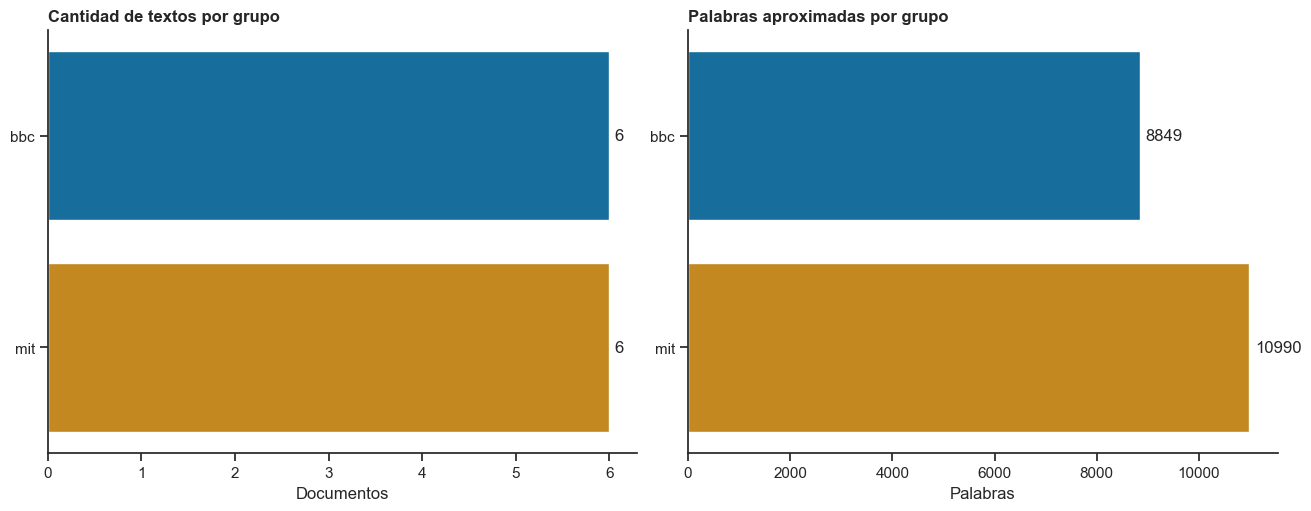

In [14]:
# Grafico 1: cantidad de textos por grupo.
# Grafico 2: cantidad aproximada de palabras por grupo.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    legend=False,
    ax=axes[0],
)

axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")

for contenedor in axes[0].containers:
    axes[0].bar_label(contenedor, fmt="%.0f", padding=4)

sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    legend=False,
    ax=axes[1],
)

axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")

for contenedor in axes[1].containers:
    axes[1].bar_label(contenedor, fmt="%.0f", padding=4)

sns.despine()
plt.show()

Agreguen una celda Markdown nueva y anoten si ven desbalances de longitud, autoria, fechas o recorte.

HAY QUE COMPLETAR ESTO Y CORRER A PARTIR DE ACÁ

## 4. Inspeccion con spaCy (`es_core_news_md`)

En esta parte no basta con ejecutar. Miren como el modelo tokeniza, lematiza, etiqueta y reconoce entidades en su corpus.

**Vocabulario de esta seccion**

- **pipeline**: secuencia de operaciones que el modelo aplica al texto;
- **token**: unidad de texto separada por el modelo;
- **lema**: forma base de una palabra;
- **POS**: categoria gramatical general;
- **dependencia**: relacion sintactica entre palabras;
- **entidad**: nombre propio, organizacion, lugar u otra expresion relevante;
- **rasgo morfologico**: informacion como numero, genero o persona.

In [16]:
try:
    import spacy
    from spacy.matcher import Matcher
    nlp = spacy.load(MODELO_SPACY)
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalen el modelo con: python -m spacy download es_core_news_md"
    ) from error

# Ajustamos algunas stopwords que pueden resultar utiles en corpus en espanol.
nlp.vocab["él"].is_stop = True
nlp.vocab["ella"].is_stop = True

print(f"Modelo cargado: {MODELO_SPACY}")
print("Pipeline activo:")
display(pd.Series(nlp.pipe_names))

Modelo cargado: es_core_news_md
Pipeline activo:


0            tok2vec
1      morphologizer
2             parser
3    attribute_ruler
4         lemmatizer
5                ner
dtype: str

In [27]:
# 'pipe' procesa muchos textos de una vez.
# Lo usamos porque todo el corpus pasa por el mismo pipeline.
textos_corpus = df[COLUMNA_TEXTO].tolist()
docs_base = list(nlp.pipe(textos_corpus))

print(f"Documentos procesados con spaCy: {len(docs_base)}")

Documentos procesados con spaCy: 12


In [34]:
def normalizar_lemma(token):
    # 'lemma_' es la forma base de una palabra segun el modelo.
    lema = token.lemma_.strip().lower()

    # A veces spaCy devuelve un lema vacio o '-PRON-'.
    # En esos casos usamos la forma original en minuscula.
    if not lema or lema == "-pron-":
        lema = token.text.lower()

    return lema

texto_muestra = df.loc[0, COLUMNA_TEXTO]
fragmento = texto_muestra[:350]
doc_fragmento = nlp(fragmento)

registros_tokens = []

for indice, token in enumerate(doc_fragmento):
    if indice >= 25:
        break

    if token.is_space:
        continue

    # 'pos_' es la categoria gramatical general.
    # 'tag_' es una etiqueta mas especifica.
    # 'dep_' muestra la relacion sintactica.
    # 'morph' guarda rasgos como numero, genero o persona.
    registro_token = {
        "token": token.text,
        "lemma": normalizar_lemma(token),
        "pos": token.pos_,
        "tag": token.tag_,
        "dep": token.dep_,
        "ent": token.ent_type_ if token.ent_type_ else "-",
        "morph": str(token.morph) if str(token.morph) else "-",
    }
    registros_tokens.append(registro_token)

tabla_tokens = pd.DataFrame(registros_tokens)
display(tabla_tokens)

,token,lemma,pos,tag,dep,ent,morph
0,La,el,DET,DET,det,-,Definite=Def|Gender=Fem|Number=Sing|PronType=Art
1,inteligencia,inteligencia,NOUN,NOUN,nsubj,-,Gender=Fem|Number=Sing
2,artificial,artificial,ADJ,ADJ,amod,-,Number=Sing
3,avanza,avanzar,VERB,VERB,ROOT,-,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
4,rápidamente,rápidamente,ADV,ADV,advmod,-,-
5,en,en,ADP,ADP,case,-,-
6,el,el,DET,DET,det,-,Definite=Def|Gender=Masc|Number=Sing|PronType=Art
7,ámbito,ámbito,NOUN,NOUN,obl,-,Gender=Masc|Number=Sing
8,empresarial,empresarial,ADJ,ADJ,amod,-,Number=Sing
9,",",",",PUNCT,PUNCT,punct,-,PunctType=Comm


In [ ]:
from collections import Counter


# Pasar todo a minúscula y conservar solo tokens que contengan letras


tokens_a = [
    [
        token.text.lower()
        for token in doc
        if token.is_alpha
    ]
    for doc in docs_base
]

# Aplanamos la lista 
todos_tokens_a = [token for doc in tokens_a for token in doc]

print
print(f"Total tokens: {len(todos_tokens_a)}")

# Contamos frecuencias
freq_a = Counter(todos_tokens_a)

print("\nTop 10 palabras más frecuentes:")
for palabra, cuenta in freq_a.most_common(10):
    print(f"{palabra:20} -> {cuenta}")

Total tokens: 20768

Top 10 palabras más frecuentes:
de                   -> 1383
que                  -> 777
la                   -> 695
en                   -> 593
y                    -> 453
a                    -> 424
el                   -> 391
los                  -> 368
un                   -> 281
una                  -> 223


In [45]:

from collections import Counter

# Aplicamos stopwords para eliminar articulos a todo el corpus
tokens_limpios = [
    [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop
    ]
    for doc in docs_base
]

# Aplanamos la lista
todos_tokens = [token for doc in tokens_limpios for token in doc]

# Contamos frecuencias
freq = Counter(todos_tokens)

print("Top 10 palabras:")
for palabra, cuenta in freq.most_common(10):
    print(palabra, "->", cuenta)

Top 10 palabras:
ia -> 205
modelo -> 94
empresa -> 81
sistema -> 78
dato -> 76
mundo -> 70
openai -> 54
año -> 53
persona -> 49
afirmar -> 48


In [46]:
def normalizar_lemma(token):
    # 'lemma_' es la forma base de una palabra segun el modelo.
    lema = token.lemma_.strip().lower()

    # A veces spaCy devuelve un lema vacio o '-PRON-'.
    # En esos casos usamos la forma original en minuscula.
    if not lema or lema == "-pron-":
        lema = token.text.lower()

    return lema


# Tomamos un texto de ejemplo
texto_muestra = df.loc[0, COLUMNA_TEXTO]
fragmento = texto_muestra[:350]
doc_fragmento = nlp(fragmento)

registros_tokens = []

for indice, token in enumerate(doc_fragmento):
    if indice >= 25:
        break

    # ❌ ignoramos espacios, puntuación y stopwords
    if token.is_space or not token.is_alpha or token.is_stop:
        continue

    registro_token = {
        "token": token.text,
        "lemma": normalizar_lemma(token),
        "pos": token.pos_,
        "tag": token.tag_,
        "dep": token.dep_,
        "ent": token.ent_type_ if token.ent_type_ else "-",
        "morph": str(token.morph) if str(token.morph) else "-",
    }

    registros_tokens.append(registro_token)

tabla_tokens = pd.DataFrame(registros_tokens)
display(tabla_tokens)

,token,lemma,pos,tag,dep,ent,morph
0,inteligencia,inteligencia,NOUN,NOUN,nsubj,-,Gender=Fem|Number=Sing
1,artificial,artificial,ADJ,ADJ,amod,-,Number=Sing
2,avanza,avanzar,VERB,VERB,ROOT,-,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
3,rápidamente,rápidamente,ADV,ADV,advmod,-,-
4,ámbito,ámbito,NOUN,NOUN,obl,-,Gender=Masc|Number=Sing
5,empresarial,empresarial,ADJ,ADJ,amod,-,Number=Sing
6,pasando,pasar,VERB,VERB,advcl,-,VerbForm=Ger
7,experimentación,experimentación,NOUN,NOUN,obj,-,Gender=Fem|Number=Sing
8,cotidiano,cotidiano,ADJ,ADJ,amod,-,Gender=Masc|Number=Sing
9,organizaciones,organización,NOUN,NOUN,nsubj,MISC,Gender=Fem|Number=Plur


In [47]:
print("VERBOS Y SUS LEMAS:\n")

for doc in docs_base:
    for token in doc:
        # Filtramos solo verbos reales (no stopwords ni símbolos)
        if token.pos_ == "VERB" and token.is_alpha:
            print(f"{token.text:15} -> {token.lemma_}")

VERBOS Y SUS LEMAS:

avanza          -> avanzar
pasando         -> pasar
desplegando     -> desplegar
utilizado       -> utilizar
integra         -> integrar
descubriendo    -> descubrir
dependen        -> depender
introduce       -> introducir
acceder         -> acceder
comprender      -> comprender
sustenta        -> sustentar
generar         -> generar
tomar           -> tomar
afirma          -> afirmar
produciendo     -> producir
dice            -> decir
mueve           -> mover
ejercer         -> ejercer
genera          -> generar
ayuda           -> ayudar
perjudica       -> perjudicar
aportar         -> aportar
necesitan       -> necesitar
vaya            -> ir
afirma          -> afirmar
permite         -> permitir
escalar         -> escalar
coordinar       -> coordinar
asegurar        -> asegurar
refleje         -> reflejar
tomar           -> tomar
replanteándose  -> replantear él
trasladar       -> trasladar
buscan          -> buscar
conectar        -> conectar
preservando     

In [48]:
# Esta funcion arma una tabla de frecuencias para una familia de etiquetas.
def tabla_etiquetas(docs, atributo, incluir_vacios=False):
    contador = Counter()

    for doc in docs:
        for token in doc:
            if token.is_space:
                continue

            valor = getattr(token, atributo)

            if not valor and not incluir_vacios:
                continue

            if not valor:
                valor = "-"

            contador[valor] += 1

    filas = []

    for etiqueta, frecuencia in contador.most_common():
        descripcion = "-"

        if etiqueta != "-":
            explicacion = spacy.explain(etiqueta)
            if explicacion:
                descripcion = explicacion

        fila = {
            "etiqueta": etiqueta,
            "descripcion": descripcion,
            "frecuencia": frecuencia,
        }
        filas.append(fila)

    return pd.DataFrame(filas)

In [20]:
tabla_pos = tabla_etiquetas(docs_base, "pos_")

print("POS detectadas")
display(tabla_pos.head(15))

POS detectadas


,etiqueta,descripcion,frecuencia
0,NOUN,noun,4482
1,ADP,adposition,3387
2,PUNCT,punctuation,2973
3,DET,determiner,2903
4,VERB,verb,2463
5,ADJ,adjective,1660
6,PROPN,proper noun,1290
7,PRON,pronoun,1236
8,ADV,adverb,994
9,AUX,auxiliary,992


In [49]:
tabla_tag = tabla_etiquetas(docs_base, "tag_")

print("TAG detectadas")
display(tabla_tag.head(15))

TAG detectadas


,etiqueta,descripcion,frecuencia
0,NOUN,noun,4482
1,ADP,adposition,3387
2,PUNCT,punctuation,2973
3,DET,determiner,2903
4,VERB,verb,2463
5,ADJ,adjective,1660
6,PROPN,proper noun,1290
7,PRON,pronoun,1236
8,ADV,adverb,994
9,AUX,auxiliary,992


In [50]:
tabla_dep = tabla_etiquetas(docs_base, "dep_")

print("Dependencias detectadas")
display(tabla_dep.head(15))

Dependencias detectadas


c:\Tecnicas_habla\ifts24-lab-pln-2026\.venv\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:pv' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
c:\Tecnicas_habla\ifts24-lab-pln-2026\.venv\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:pass' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
c:\Tecnicas_habla\ifts24-lab-pln-2026\.venv\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:impers' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W

,etiqueta,descripcion,frecuencia
0,det,determiner,3007
1,punct,punctuation,2970
2,case,case marking,2816
3,nmod,modifier of nominal,1541
4,obj,object,1519
5,nsubj,nominal subject,1405
6,amod,adjectival modifier,1297
7,advmod,adverbial modifier,1121
8,mark,marker,1071
9,ROOT,root,975


In [51]:
tabla_ent = tabla_etiquetas(docs_base, "ent_type_")

print("Entidades detectadas")
display(tabla_ent.head(15))

Entidades detectadas


,etiqueta,descripcion,frecuencia
0,MISC,"Miscellaneous entities, e.g. events, nationalities, products or works of art",1179
1,ORG,"Companies, agencies, institutions, etc.",309
2,PER,Named person or family.,293
3,LOC,"Non-GPE locations, mountain ranges, bodies of water",203


In [52]:
def tabla_morph(docs):
    contador = Counter()

    for doc in docs:
        for token in doc:
            if token.is_space:
                continue

            rasgos = str(token.morph)

            if not rasgos:
                rasgos = "-"

            contador[rasgos] += 1

    filas = []

    for rasgos, frecuencia in contador.most_common():
        filas.append({"morph": rasgos, "frecuencia": frecuencia})

    return pd.DataFrame(filas)

tabla_morf = tabla_morph(docs_base)

print("Rasgos morfologicos detectados")
display(tabla_morf.head(15))

Rasgos morfologicos detectados


,morph,frecuencia
0,-,6861
1,Gender=Masc|Number=Sing,1511
2,Gender=Fem|Number=Sing,1456
3,PunctType=Comm,1186
4,Gender=Masc|Number=Plur,974
5,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin,941
6,PunctType=Peri,939
7,Gender=Fem|Number=Plur,716
8,Definite=Def|Gender=Fem|Number=Sing|PronType=Art,685
9,VerbForm=Inf,656


Agreguen una celda Markdown nueva y registren al menos **dos limites o errores** que observen en el pipeline de `spaCy` sobre su corpus.

Uno de los límites que se observa es que, aun aplicando stopwords, siguen apareciendo palabras como determinantes con bastante frecuencia. Esto indica que el filtrado no es completamente efectivo y puede afectar la interpretación del contenido real del texto.

Otro problema es que muchas entidades son clasificadas como “misceláneas” (MISC), lo que muestra que el modelo no logra identificar con precisión el tipo de entidad. Esto limita el análisis semántico del corpus.Por eso, sería conveniente realizar algunos ajustes adicionales.

4B. En esta sección se realiza un ajuste en el enfoque del análisis, pasando de etiquetas a entidades concretas. En lugar de observar categorías gramaticales, se analizan personas, organizaciones y lugares presentes en el corpus, lo que permite interpretar mejor el contenido real de los textos.

In [53]:
registros_entidades = []

for doc_id, titulo, grupo, doc in zip(df["id"], df["titulo"], df[COLUMNA_GRUPO], docs_base):
    for ent in doc.ents:
        fila = {
            "id": doc_id,
            "titulo": titulo,
            "grupo": grupo,
            "texto_entidad": ent.text,
            "etiqueta": ent.label_,
        }
        registros_entidades.append(fila)

df_entidades = pd.DataFrame(registros_entidades)

if df_entidades.empty:
    print("No se detectaron entidades en el corpus.")
else:
    print("Muestra de entidades detectadas")
    display(df_entidades.head(20))

Muestra de entidades detectadas


,id,titulo,grupo,texto_entidad,etiqueta
0,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Las organizaciones están desplegando copilotos,MISC
1,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Para finales de 2025,MISC
2,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,La IA,MISC
3,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Irfan Khan,PER
4,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,SAP Data & Analytics,ORG
5,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,La velocidad sin juicio,MISC
6,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,De hecho,MISC
7,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Khan,MISC
8,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,El tejido de datos adecuado,MISC
9,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Este cambio está impulsando un interés creciente en el data fabric,MISC


In [55]:
display(df_entidades.groupby("grupo").head(20))

,id,titulo,grupo,texto_entidad,etiqueta
0,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Las organizaciones están desplegando copilotos,MISC
1,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Para finales de 2025,MISC
2,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,La IA,MISC
3,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Irfan Khan,PER
4,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,SAP Data & Analytics,ORG
5,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,La velocidad sin juicio,MISC
6,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,De hecho,MISC
7,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Khan,MISC
8,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,El tejido de datos adecuado,MISC
9,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Este cambio está impulsando un interés creciente en el data fabric,MISC


In [56]:
if df_entidades.empty:
    tabla_tipos_entidad = pd.DataFrame(
        columns=["grupo", "etiqueta", "frecuencia"]
    )
else:
    tabla_tipos_entidad = (
        df_entidades
        .groupby(["grupo", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )

print("Tipos de entidad por grupo")
display(tabla_tipos_entidad)

Tipos de entidad por grupo


,grupo,etiqueta,frecuencia
1,bbc,MISC,162
2,bbc,ORG,130
3,bbc,PER,108
0,bbc,LOC,70
5,mit,MISC,331
6,mit,ORG,120
7,mit,PER,101
4,mit,LOC,80


Al comparar los tipos de entidades por grupo, se observa que en MIT predomina fuertemente la categoría MISC, lo que indica que el modelo no logra clasificar correctamente muchas entidades. En cambio, en BBC hay una distribución más equilibrada, con mayor presencia de organizaciones y personas. Esto sugiere que el modelo funciona mejor en los textos de BBC y presenta más limitaciones en los de MIT.

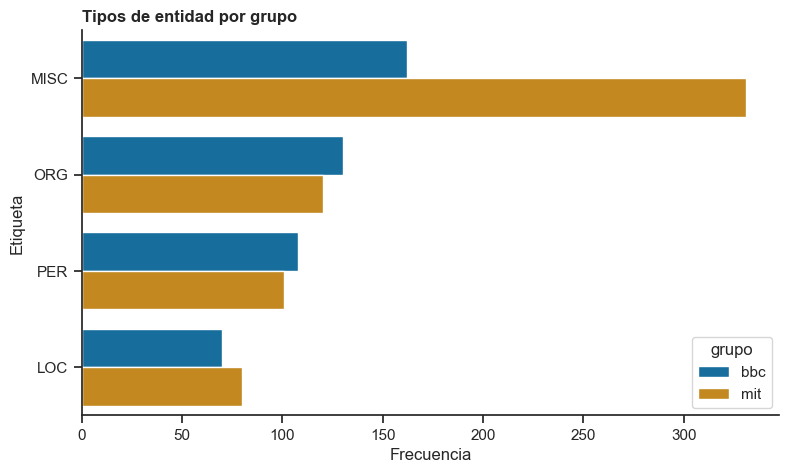

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

if tabla_tipos_entidad.empty:
    print("No hay entidades para graficar.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))

    sns.barplot(
        data=tabla_tipos_entidad,
        x="frecuencia",
        y="etiqueta",
        hue="grupo",
        ax=ax
    )

    ax.set_title("Tipos de entidad por grupo", loc="left", fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Etiqueta")

    sns.despine()
    plt.show()

In [58]:
if df_entidades.empty:
    tabla_entidades_concretas = pd.DataFrame(
        columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"]
    )
    top_entidades_concretas = tabla_entidades_concretas.copy()

else:
    # Contamos entidades por grupo
    tabla_entidades_concretas = (
        df_entidades
        .groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )

    # Nos quedamos con el TOP 10 por grupo (BBC vs MIT)
    top_entidades_concretas = (
        tabla_entidades_concretas
        .groupby("grupo")
        .head(10)
    )

print("Entidades concretas por grupo")
display(top_entidades_concretas)

Entidades concretas por grupo


,grupo,texto_entidad,etiqueta,frecuencia
37,bbc,ChatGPT,MISC,28
87,bbc,Google,ORG,24
99,bbc,IA,MISC,24
157,bbc,OpenAI,ORG,17
100,bbc,IA,ORG,14
213,bbc,Viktoria,PER,12
26,bbc,BBC,ORG,11
145,bbc,Mythos,MISC,10
117,bbc,Kosmyna,PER,9
20,bbc,Anthropic,PER,8


Al observar las entidades más frecuentes, se ve que el modelo reconoce correctamente muchas organizaciones y personas, como Google, OpenAI o BBC. Sin embargo, aparecen varios errores de clasificación: por ejemplo, “ChatGPT” y “Google DeepMind” son etiquetados como MISC en lugar de ORG, y “Meta” incluso aparece como LOC. Además, términos como “IA” se clasifican de forma inconsistente en distintas categorías. Esto muestra que el modelo tiene dificultades para clasificar correctamente entidades tecnológicas actuales.

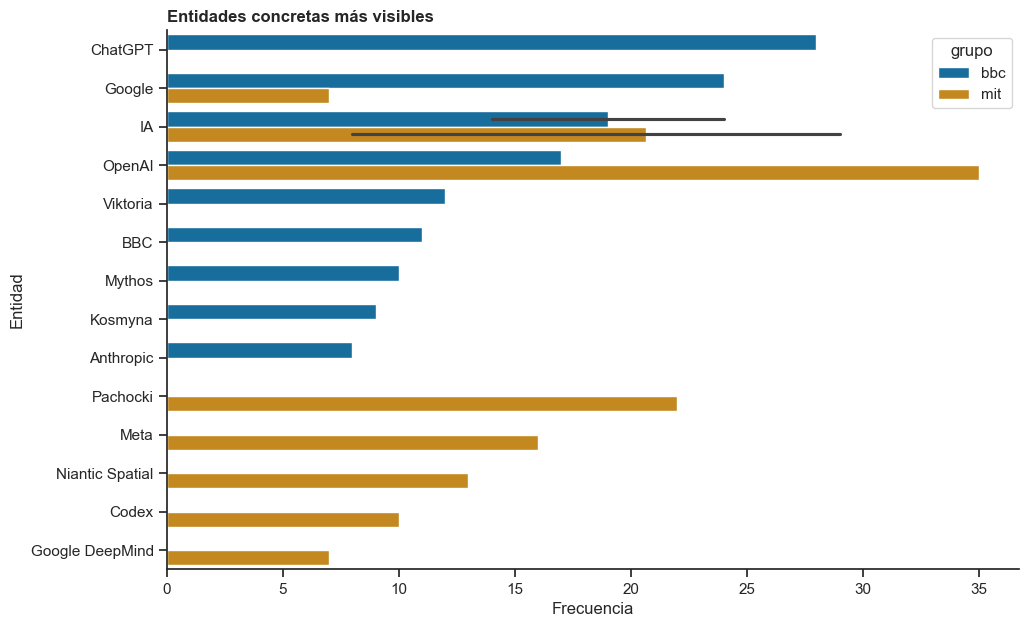

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

if top_entidades_concretas.empty:
    print("No hay entidades concretas para graficar.")
else:
    fig, ax = plt.subplots(figsize=(11, 7))

    sns.barplot(
        data=top_entidades_concretas,
        x="frecuencia",
        y="texto_entidad",
        hue="grupo",
        ax=ax
    )

    ax.set_title("Entidades concretas más visibles", loc="left", fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Entidad")

    sns.despine()
    plt.show()

In [62]:
if tabla_entidades_concretas.empty:
    entidades_org = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    entidades_loc = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])

else:
    # Filtramos organizaciones (ORG)
    entidades_org = tabla_entidades_concretas[
        tabla_entidades_concretas["etiqueta"] == "ORG"
    ]

    # Filtramos lugares (LOC)
    entidades_loc = tabla_entidades_concretas[
        tabla_entidades_concretas["etiqueta"] == "LOC"
    ]



In [63]:
print("Organizaciones BBC")
org_bbc = entidades_org[entidades_org["grupo"] == "bbc"]

if org_bbc.empty:
    print("No hay organizaciones en BBC")
else:
    display(org_bbc.head(10))


print("\nOrganizaciones MIT")
org_mit = entidades_org[entidades_org["grupo"] == "mit"]

if org_mit.empty:
    print("No hay organizaciones en MIT")
else:
    display(org_mit.head(10))


print("\nLugares BBC")
loc_bbc = entidades_loc[entidades_loc["grupo"] == "bbc"]

if loc_bbc.empty:
    print("No hay lugares en BBC")
else:
    display(loc_bbc.head(10))


print("\nLugares MIT")
loc_mit = entidades_loc[entidades_loc["grupo"] == "mit"]

if loc_mit.empty:
    print("No hay lugares en MIT")
else:
    display(loc_mit.head(10))

Organizaciones BBC


,grupo,texto_entidad,etiqueta,frecuencia
87,bbc,Google,ORG,24
157,bbc,OpenAI,ORG,17
100,bbc,IA,ORG,14
26,bbc,BBC,ORG,11
165,bbc,Pichai,ORG,7
154,bbc,Nvidia,ORG,6
196,bbc,Time,ORG,5
3,bbc,AI,ORG,4
21,bbc,Apple,ORG,4
139,bbc,Microsoft,ORG,4



Organizaciones MIT


,grupo,texto_entidad,etiqueta,frecuencia
471,mit,OpenAI,ORG,35
368,mit,IA,ORG,29
357,mit,Google,ORG,7
459,mit,Niantic,ORG,5
380,mit,JEPA,ORG,4
453,mit,Microsoft,ORG,3
233,mit,AMI,ORG,2
234,mit,AMI Labs,ORG,2
456,mit,NYU,ORG,2
479,mit,Pentágono,ORG,2



Lugares BBC


,grupo,texto_entidad,etiqueta,frecuencia
137,bbc,Meta,LOC,6
68,bbc,Estados Unidos,LOC,5
141,bbc,Ming,LOC,4
172,bbc,Reino Unido,LOC,4
184,bbc,Silicon Valley,LOC,4
98,bbc,IA,LOC,3
191,bbc,Svitlana,LOC,3
27,bbc,Banco de Inglaterra,LOC,2
34,bbc,Character,LOC,2
38,bbc,China,LOC,2



Lugares MIT


,grupo,texto_entidad,etiqueta,frecuencia
446,mit,Meta,LOC,16
366,mit,IA,LOC,8
478,mit,París,LOC,6
301,mit,EE UU,LOC,4
264,mit,China,LOC,3
344,mit,Francia,LOC,3
467,mit,Nueva York,LOC,3
523,mit,Silicon Valley,LOC,3
263,mit,Chicago,LOC,2
328,mit,Estados Unidos,LOC,2


Al analizar las organizaciones y lugares, se observa que en BBC predominan empresas tecnológicas y medios como Google, OpenAI o BBC, mientras que en MIT aparecen más instituciones académicas y términos técnicos como NYU o JEPA.

Sin embargo, también se detectan errores en el modelo. Por ejemplo, “Meta” es clasificado como lugar (LOC) cuando en realidad es una organización, y “IA” aparece tanto como organización como lugar. 

Esto nos muestra que aunque spaCy reconoce entidades relevantes, tiene dificultades para clasificarlas correctamente.

## 5. Stopwords: `spaCy` vs `NLTK`

Comparen ambos enfoques antes de decidir. No existe una lista universalmente correcta.

**Vocabulario de esta seccion**

- **stopword**: palabra muy frecuente que muchas veces aporta poco para diferenciar textos;
- **lista base**: conjunto inicial de stopwords que tomamos de una libreria;
- **lista ajustada**: lista base modificada segun las necesidades del corpus.

In [64]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

stopwords_nltk = set(stopwords.words("spanish"))
stopwords_nltk.add("él")

stopwords_spacy = set(nlp.Defaults.stop_words)
stopwords_spacy.add("él")

print(f"Stopwords spaCy: {len(stopwords_spacy)}")
print(f"Stopwords NLTK: {len(stopwords_nltk)}")

Stopwords spaCy: 521
Stopwords NLTK: 313


In [72]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

stopwords_nltk = set(stopwords.words("spanish"))
stopwords_spacy = set(nlp.Defaults.stop_words)

# Stopwords extra adaptadas a tu corpus
stopwords_extra = {"él", "ella", "ia", "ai"}

for palabra in stopwords_extra:
    stopwords_nltk.add(palabra)
    stopwords_spacy.add(palabra)

print(f"Stopwords spaCy: {len(stopwords_spacy)}")
print(f"Stopwords NLTK: {len(stopwords_nltk)}")

Stopwords spaCy: 523
Stopwords NLTK: 315


In [73]:
# Comparamos algunas diferencias entre listas.
solo_spacy = stopwords_spacy - stopwords_nltk
solo_nltk = stopwords_nltk - stopwords_spacy

lista_solo_spacy = list(solo_spacy)
lista_solo_spacy = sorted(lista_solo_spacy)
muestra_solo_spacy = lista_solo_spacy[:20]

lista_solo_nltk = list(solo_nltk)
lista_solo_nltk = sorted(lista_solo_nltk)
muestra_solo_nltk = lista_solo_nltk[:20]

print("Ejemplos de palabras que aparecen solo en spaCy:")
display(pd.Series(muestra_solo_spacy))

print("Ejemplos de palabras que aparecen solo en NLTK:")
display(pd.Series(muestra_solo_nltk))

Ejemplos de palabras que aparecen solo en spaCy:


0             acuerdo
1            adelante
2              ademas
3              además
4              afirmó
5              agregó
6                 ahi
7               ahora
8                 ahí
9              alguna
10             alguno
11              algún
12               alli
13               allí
14          alrededor
15              ambos
16           anterior
17             apenas
18    aproximadamente
19              aquel
dtype: str

Ejemplos de palabras que aparecen solo en NLTK:


0          erais
1       estabais
2        estabas
3          estad
4         estada
5        estadas
6        estando
7      estaremos
8        estarán
9        estarás
10        estaré
11      estaréis
12       estaría
13     estaríais
14    estaríamos
15      estarían
16      estarías
17       estemos
18        estuve
19     estuviera
dtype: str

In [99]:
def texto_contenido_desde_doc(doc, stopwords_base):
    # Esta funcion arma una version reducida del texto.
    # Conserva solo palabras alfabeticas que no sean stopwords.
    tokens = []

    for token in doc:
        if not token.is_alpha:
            continue

        forma = token.text.lower()
        lema = normalizar_lemma(token)

        if forma in stopwords_base:
            continue

        if lema in stopwords_base:
            continue

        tokens.append(lema)

    texto_limpio = " ".join(tokens)
    return texto_limpio

In [100]:
textos_spacy_stop = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_spacy)
    textos_spacy_stop.append(texto_limpio)

df["texto_spacy_stop"] = textos_spacy_stop

display(df[["titulo", "texto_spacy_stop"]].head())

,titulo,texto_spacy_stop
0,La IA necesita un sólido tejido de datos para aportar valor empresarial,inteligencia artificial avanzar rápidamente ámbito empresarial pasar experimentación cotidiano organización desplegar copiloto agente sistema predictivo fin...
1,Por qué nuestra opinión sobre la IA está tan dividida,industria detener index stanford compendio anual resultado tendencia clave oportunidad tomar perspectiva maratón esprint cabo informe año publicado repleto ...
2,OpenAI está volcando todos sus esfuerzos en desarrollar un investigador completamente automatizado,openai reorientar esfuerzo investigación volcar recurso desafío firma san francisco fijar objetivo construir denominar investigador sistema totalmente autom...
3,Cómo Pokémon Go dota a los robots de reparto de una visión del mundo de precisión milimétrica,pokémon go éxito mundial realidad aumentado lanzado niantic empresa escindido google giro ra mastodóntico franquicia pokémon convertir rápidamente fenómeno ...
4,Los 14 términos de IA que marcaron 2025,superinteligencia gente empezar entusiasmar él proponer nombre forma futuro ultrapotente tecnología traer consecuencia utópica distópica humanidad superinte...


In [101]:
textos_nltk_stop = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_nltk)
    textos_nltk_stop.append(texto_limpio)

df["texto_nltk_stop"] = textos_nltk_stop

display(df[["titulo", "texto_nltk_stop"]].head())

,titulo,texto_nltk_stop
0,La IA necesita un sólido tejido de datos para aportar valor empresarial,inteligencia artificial avanzar rápidamente ámbito empresarial pasar experimentación uso cotidiano organización desplegar copiloto agente sistema predictivo...
1,Por qué nuestra opinión sobre la IA está tan dividida,industria detener index stanford compendio anual resultado tendencia clave oportunidad tomar perspectiva maratón esprint fin cabo informe año publicado hoy ...
2,OpenAI está volcando todos sus esfuerzos en desarrollar un investigador completamente automatizado,openai reorientar esfuerzo investigación volcar recurso nuevo gran desafío firma san francisco fijar objetivo construir denominar investigador sistema total...
3,Cómo Pokémon Go dota a los robots de reparto de una visión del mundo de precisión milimétrica,pokémon go primero gran éxito mundial realidad aumentado lanzado niantic empresa escindido google giro ra mastodóntico franquicia pokémon convertir rápidame...
4,Los 14 términos de IA que marcaron 2025,superinteligencia gente empezar entusiasmar él ir proponer nombre forma futuro ultrapotente tecnología poder traer consecuencia utópica distópica humanidad ...


In [102]:
def obtener_top_terminos_por_grupo(dataframe, columna_texto, top_n=10):
    # Esta funcion cuenta los terminos mas frecuentes dentro de cada grupo.
    filas = []

    grupos = dataframe.groupby(COLUMNA_GRUPO)

    for grupo, subconjunto in grupos:
        texto_total = " ".join(subconjunto[columna_texto])
        lista_terminos = texto_total.split()
        contador = Counter(lista_terminos)

        # 'most_common' devuelve pares (termino, frecuencia)
        # ordenados de mayor a menor.
        top = contador.most_common(top_n)

        for termino, frecuencia in top:
            fila = {
                "grupo": grupo,
                "termino": termino,
                "frecuencia": frecuencia,
            }
            filas.append(fila)

    tabla_top = pd.DataFrame(filas)
    return tabla_top

In [103]:
top_spacy_stop = obtener_top_terminos_por_grupo(df, "texto_spacy_stop", top_n=TOP_N)

print("Top con stopwords de spaCy")
display(top_spacy_stop)

Top con stopwords de spaCy


,grupo,termino,frecuencia
0,bbc,él,50
1,bbc,chatbot,29
2,bbc,chatgpt,28
3,bbc,google,26
4,bbc,año,26
5,bbc,empresa,26
6,bbc,inteligencia,24
7,bbc,persona,23
8,bbc,utilizar,21
9,bbc,forma,21


In [104]:
top_nltk_stop = obtener_top_terminos_por_grupo(df, "texto_nltk_stop", top_n=TOP_N)

print("Top con stopwords de NLTK")
display(top_nltk_stop)

Top con stopwords de NLTK


,grupo,termino,frecuencia
0,bbc,poder,78
1,bbc,él,51
2,bbc,decir,42
3,bbc,chatbot,29
4,bbc,ser,29
5,bbc,chatgpt,28
6,bbc,afirmar,27
7,bbc,google,26
8,bbc,año,26
9,bbc,empresa,26


In [106]:
palabras_a_sacar = {"él", "el", "la", "lo", "los", "las", "si", "sí"}

top_spacy_stop = top_spacy_stop[
    ~top_spacy_stop["termino"].isin(palabras_a_sacar)
]

top_nltk_stop = top_nltk_stop[
    ~top_nltk_stop["termino"].isin(palabras_a_sacar)
]

print("Top con stopwords de spaCy")
display(top_spacy_stop)
print("Top con stopwords de NLTK")
display(top_nltk_stop)

Top con stopwords de spaCy


,grupo,termino,frecuencia
1,bbc,chatbot,29
2,bbc,chatgpt,28
3,bbc,google,26
4,bbc,año,26
5,bbc,empresa,26
6,bbc,inteligencia,24
7,bbc,persona,23
8,bbc,utilizar,21
9,bbc,forma,21
10,bbc,artificial,21


Top con stopwords de NLTK


,grupo,termino,frecuencia
0,bbc,poder,78
2,bbc,decir,42
3,bbc,chatbot,29
4,bbc,ser,29
5,bbc,chatgpt,28
6,bbc,afirmar,27
7,bbc,google,26
8,bbc,año,26
9,bbc,empresa,26
10,bbc,inteligencia,24


Agreguen una celda Markdown nueva y respondan: **que lista sirve mejor para este corpus y por que**.

Spacy tiene una lista de stopwords más amplia en general, en este corpus no se observan diferencias importantes con respecto a NLTK, ya que los resultados obtenidos son muy similares. Esto indica que ambas listas terminan filtrando palabras parecidas y que fue necesario realizar ajustes manuales para mejorar el análisis.

## 6. Ajuste humano del pipeline

Completen estas celdas. Para aprobar esta parte deben hacer al menos **dos ajustes**:

- **uno lexico**: stopwords propias y/o correcciones de lemas;
- **uno estructural**: `Matcher` y/o `EntityRuler`.

In [ ]:
BASE_STOPWORDS = "spacy"  # opciones: "spacy" o "nltk"

STOPWORDS_EXTRA = {
    # "palabra",
}

STOPWORDS_EXCLUIR = {
    # "palabra",
}

CORRECCIONES_LEMAS = {
    # "sabés": "saber",
}

PATRONES_MATCHER = {
    # "LOCUCION": [[{"LOWER": "inteligencia"}, {"LOWER": "artificial"}]],
}

PATRONES_ENTIDADES = [
    # {"label": "ORG", "pattern": "CONICET"},
]

In [ ]:
# Elegimos una lista base de stopwords.
if BASE_STOPWORDS == "spacy":
    stopwords_base = set(stopwords_spacy)
else:
    stopwords_base = set(stopwords_nltk)

# Sumamos palabras que queremos tratar como stopwords.
stopwords_ajustadas = set(stopwords_base)

for palabra in STOPWORDS_EXTRA:
    stopwords_ajustadas.add(palabra)

# Quitamos palabras que no queremos perder en el analisis.
for palabra in STOPWORDS_EXCLUIR:
    if palabra in stopwords_ajustadas:
        stopwords_ajustadas.remove(palabra)

print(f"Lista base elegida: {BASE_STOPWORDS}")
print(f"Stopwords ajustadas: {len(stopwords_ajustadas)}")

In [ ]:
# Cargamos un pipeline nuevo para no mezclar este ajuste con el analisis anterior.
nlp_ajustado = spacy.load(MODELO_SPACY)
nlp_ajustado.vocab["él"].is_stop = True

# Marcamos como stopword cada palabra agregada a mano.
for palabra in STOPWORDS_EXTRA:
    nlp_ajustado.vocab[palabra].is_stop = True

# Desmarcamos las palabras que queremos conservar.
for palabra in STOPWORDS_EXCLUIR:
    nlp_ajustado.vocab[palabra].is_stop = False

print("Pipeline ajustado cargado.")

In [ ]:
# 'EntityRuler' sirve para forzar entidades que el modelo no reconoce bien.
if PATRONES_ENTIDADES:
    ruler = nlp_ajustado.add_pipe("entity_ruler", config={"overwrite_ents": True}, before="ner")
    ruler.add_patterns(PATRONES_ENTIDADES)
    print("EntityRuler agregado.")
else:
    print("No se agregaron patrones de entidades.")

In [ ]:
# 'Matcher' sirve para detectar patrones de varias palabras.
matcher = Matcher(nlp_ajustado.vocab)

for nombre, patrones in PATRONES_MATCHER.items():
    matcher.add(nombre, patrones)

print("Matcher preparado.")

In [ ]:
def lema_ajustado(token):
    # Si la forma aparece en el diccionario manual, usamos esa correccion.
    forma = token.text.lower()

    if forma in CORRECCIONES_LEMAS:
        return CORRECCIONES_LEMAS[forma]

    return normalizar_lemma(token)

# Volvemos a procesar el corpus con el pipeline ajustado.
textos_corpus_ajustado = df[COLUMNA_TEXTO].tolist()
docs_ajustados = list(nlp_ajustado.pipe(textos_corpus_ajustado))

print(f"Documentos procesados con el pipeline ajustado: {len(docs_ajustados)}")

In [ ]:
registros_matcher = []
textos_modelo = []
entidades_ajustadas = []

for doc_id, doc in zip(df["id"], docs_ajustados):
    contenido = []

    for token in doc:
        if not token.is_alpha:
            continue

        forma = token.text.lower()
        lema = lema_ajustado(token)

        if forma in stopwords_ajustadas:
            continue

        if lema in stopwords_ajustadas:
            continue

        contenido.append(lema)

    texto_limpio = " ".join(contenido)
    textos_modelo.append(texto_limpio)

    lista_entidades = []
    for ent in doc.ents:
        lista_entidades.append((ent.text, ent.label_))
    entidades_ajustadas.append(lista_entidades)

    coincidencias = matcher(doc)
    for match_id, inicio, fin in coincidencias:
        patron = nlp_ajustado.vocab.strings[match_id]
        span = doc[inicio:fin].text
        registros_matcher.append({
            "id": doc_id,
            "patron": patron,
            "span": span,
        })

In [ ]:
df["texto_modelo"] = textos_modelo
df["entidades_ajustadas"] = entidades_ajustadas

tokens_por_texto = df["texto_modelo"].str.split()
cantidad_tokens = tokens_por_texto.str.len()
df["num_tokens_modelo"] = cantidad_tokens

columnas_revision = ["titulo", COLUMNA_GRUPO, "texto_modelo", "num_tokens_modelo"]
display(df[columnas_revision].head())

In [ ]:
df_matcher = pd.DataFrame(registros_matcher)

if not df_matcher.empty:
    display(df_matcher.head(20))
else:
    print("No se registraron coincidencias de Matcher.")

Agreguen una celda Markdown nueva y expliquen en pocas lineas:

- que problema detectaron;
- que cambiaron;
- que efecto tuvo ese cambio en los resultados.

## 7. Representaciones sparse

A partir de `texto_modelo`, comparen frecuencias, distintividad y asociaciones.

**Vocabulario de esta seccion**

- **vectorizador**: herramienta que convierte texto en numeros;
- **vocabulario**: conjunto de terminos que el vectorizador conserva;
- **matriz**: tabla numerica que representa los textos;
- **bigrama**: par de palabras consecutivas;
- **Bag of Words**: representacion basada en conteos;
- **TF-IDF**: representacion que pondera que tan distintivo es un termino;
- **fit**: paso en el que el vectorizador aprende el vocabulario;
- **transform**: paso en el que el vectorizador convierte textos en numeros;
- **min_df**: frecuencia minima por documento. Si sube, el modelo descarta terminos raros;
- **max_df**: frecuencia maxima permitida para conservar un termino. Si baja, el modelo descarta terminos demasiado comunes.

In [ ]:
top_terminos_modelo = obtener_top_terminos_por_grupo(df, "texto_modelo", top_n=TOP_N)

print("Terminos frecuentes por grupo")
display(top_terminos_modelo)

In [ ]:
def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    # Esta funcion convierte una matriz numerica en una tabla legible.
    # 'toarray' pasa de una matriz dispersa a una matriz comun.
    matriz_densa = matriz.toarray()
    tabla = pd.DataFrame(matriz_densa, columns=nombres_columnas, index=nombres_filas)
    return tabla

# 'CountVectorizer' cuenta ocurrencias de terminos o n-gramas.
# 'lowercase=False' significa que el vectorizador no cambiara mayusculas por minusculas.
# En este notebook preferimos controlar esa normalizacion antes.
usar_minusculas = False

# 'ngram_range=(2, 2)' significa que vamos a trabajar solo con bigramas.
rango_ngramas = (2, 2)

# 'min_df=1' significa que conservamos terminos que aparecen al menos en 1 documento.
frecuencia_minima_documento = 1

vectorizador_bigramas = CountVectorizer(
    lowercase=usar_minusculas,
    ngram_range=rango_ngramas,
    min_df=frecuencia_minima_documento,
)

# 'fit' aprende el vocabulario de bigramas a partir de los textos.
vectorizador_bigramas.fit(df["texto_modelo"])

# 'transform' convierte los textos en una matriz numerica usando ese vocabulario.
matriz_bigramas = vectorizador_bigramas.transform(df["texto_modelo"])

# 'get_feature_names_out' devuelve la lista de terminos aprendidos por el vectorizador.
nombres_bigramas = vectorizador_bigramas.get_feature_names_out()
ids_documentos = df["id"]

tabla_bigramas_docs = matriz_a_dataframe(matriz_bigramas, nombres_bigramas, ids_documentos)
display(tabla_bigramas_docs.head())

In [ ]:
# Sumamos los bigramas dentro de cada grupo.
tabla_bigramas_con_grupo = tabla_bigramas_docs.copy()
tabla_bigramas_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

# 'sum' agrega los conteos de cada columna dentro de cada grupo.
bigramas_agrupados = tabla_bigramas_con_grupo.groupby("grupo").sum()

# '.T' transpone la tabla: filas pasan a columnas y columnas a filas.
bigramas_por_grupo = bigramas_agrupados.T

filas_bigramas = []

for grupo in bigramas_por_grupo.columns:
    serie_grupo = bigramas_por_grupo[grupo]
    # 'sort_values' ordena de mayor a menor.
    serie_ordenada = serie_grupo.sort_values(ascending=False)

    # 'head(TOP_N)' conserva solo los primeros N casos.
    top_grupo = serie_ordenada.head(TOP_N)

    for bigrama, frecuencia in top_grupo.items():
        filas_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(filas_bigramas)
display(top_bigramas)

In [ ]:
# Bag of Words cuenta volumen.
usar_minusculas_bow = False

# 'min_df=1' conserva terminos que aparecen al menos en 1 documento.
min_df_bow = 1

# 'max_df=0.95' descarta terminos que aparecen en mas del 95% de los documentos.
# Sirve para quitar palabras demasiado comunes y poco distintivas.
max_df_bow = 0.95

vectorizador_bow = CountVectorizer(
    lowercase=usar_minusculas_bow,
    min_df=min_df_bow,
    max_df=max_df_bow,
)

# 'fit' aprende que terminos formaran parte del vocabulario.
vectorizador_bow.fit(df["texto_modelo"])

# 'transform' convierte los textos en conteos numericos.
matriz_bow = vectorizador_bow.transform(df["texto_modelo"])

vocabulario_bow = vectorizador_bow.get_feature_names_out()
tabla_bow_docs = matriz_a_dataframe(matriz_bow, vocabulario_bow, df["id"])

tabla_bow_con_grupo = tabla_bow_docs.copy()
tabla_bow_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

# 'groupby' agrupa filas que comparten el mismo valor de grupo.
agrupado_bow = tabla_bow_con_grupo.groupby("grupo")

# 'mean' calcula el promedio por columna dentro de cada grupo.
tabla_bow_grupos = agrupado_bow.mean()

display(tabla_bow_grupos.head())

In [ ]:
# TF-IDF no mide solo frecuencia. Mide que tan distintivo es un termino.
usar_minusculas_tfidf = False

# Igual que antes, 'min_df=1' conserva terminos presentes al menos en 1 documento.
min_df_tfidf = 1

# Igual que antes, 'max_df=0.95' descarta terminos demasiado comunes.
max_df_tfidf = 0.95

vectorizador_tfidf = TfidfVectorizer(
    lowercase=usar_minusculas_tfidf,
    min_df=min_df_tfidf,
    max_df=max_df_tfidf,
)

# 'fit' aprende el vocabulario y las ponderaciones necesarias.
vectorizador_tfidf.fit(df["texto_modelo"])

# 'transform' convierte los textos en una matriz numerica usando ese aprendizaje.
matriz_tfidf = vectorizador_tfidf.transform(df["texto_modelo"])

vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()
tabla_tfidf_docs = matriz_a_dataframe(matriz_tfidf, vocabulario_tfidf, df["id"])

tabla_tfidf_con_grupo = tabla_tfidf_docs.copy()
tabla_tfidf_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

agrupado_tfidf = tabla_tfidf_con_grupo.groupby("grupo")
tabla_tfidf_grupos = agrupado_tfidf.mean()

display(tabla_tfidf_grupos.head())

In [ ]:
def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    filas = []

    # 'iterrows' recorre la tabla fila por fila.
    for grupo, serie in tabla_matriz.iterrows():
        serie_positivos = serie[serie > 0]

        # Ordenamos de mayor a menor para ver primero los terminos mas fuertes.
        serie_ordenada = serie_positivos.sort_values(ascending=False)

        # 'head(top_n)' conserva los primeros N terminos.
        top = serie_ordenada.head(top_n)

        for termino, valor in top.items():
            filas.append({
                "grupo": grupo,
                "termino": termino,
                nombre_valor: round(float(valor), 4),
            })

    return pd.DataFrame(filas)

top_bow = extraer_top_por_grupo(tabla_bow_grupos, top_n=TOP_N, nombre_valor="frecuencia_media")
top_tfidf = extraer_top_por_grupo(tabla_tfidf_grupos, top_n=TOP_N, nombre_valor="tfidf_medio")

print("Top por grupo segun Bag of Words")
display(top_bow)

print("Top por grupo segun TF-IDF")
display(top_tfidf)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

sns.barplot(
    data=top_tfidf,
    x="tfidf_medio",
    y="termino",
    hue="grupo",
    ax=ax,
)

ax.set_title("Terminos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("TF-IDF medio")
ax.set_ylabel("")

sns.despine(ax=ax)
plt.show()

In [ ]:
# Elegimos los primeros 8 terminos distintivos de cada grupo.
agrupado_top_tfidf = top_tfidf.groupby("grupo")
# 'head(8)' conserva los primeros 8 terminos de cada grupo.
top_ocho = agrupado_top_tfidf.head(8)
lista_terminos = top_ocho["termino"].tolist()

terminos_heatmap = []
for termino in lista_terminos:
    if termino not in terminos_heatmap:
        terminos_heatmap.append(termino)

# Volvemos a usar '.T' para que los terminos queden en el eje vertical.
matriz_heatmap = tabla_tfidf_grupos[terminos_heatmap].T

fig, ax = plt.subplots(figsize=(10, max(4, len(terminos_heatmap) * 0.35)), constrained_layout=True)

sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)

ax.set_title("Heatmap de terminos distintivos", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Termino")

plt.show()

Agreguen una celda Markdown nueva y comparen:

- que aparece como frecuente en ambos grupos;
- que aparece como distintivo en `TF-IDF`;
- que cambia entre volumen y especificidad.

## 8. Del patron al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complica.

In [ ]:
# Tomamos los 2 terminos mas distintivos de cada grupo.
agrupado_terminos = top_tfidf.groupby("grupo")
# 'head(2)' conserva los primeros 2 casos de cada grupo.
terminos_para_volver = agrupado_terminos.head(2)
# 'reset_index' recompone el indice para que la tabla quede limpia.
terminos_para_volver = terminos_para_volver.reset_index(drop=True)
display(terminos_para_volver)

In [ ]:
def extraer_fragmentos(dataframe, grupo, termino, ventana=160, max_fragmentos=2):
    registros = []

    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto_original = getattr(fila, COLUMNA_TEXTO)
        doc = nlp_ajustado(texto_original)

        for token in doc:
            coincide_lema = lema_ajustado(token) == termino
            coincide_forma = token.text.lower() == termino

            if coincide_lema or coincide_forma:
                inicio = max(0, token.idx - ventana)
                fin = min(len(texto_original), token.idx + len(token.text) + ventana)

                fragmento = texto_original[inicio:fin].strip()

                if inicio > 0:
                    fragmento = "..." + fragmento

                if fin < len(texto_original):
                    fragmento = fragmento + "..."

                registros.append({
                    "grupo": grupo,
                    "termino": termino,
                    "titulo": fila.titulo,
                    "fragmento": fragmento,
                })

                break

        if len(registros) >= max_fragmentos:
            break

    return registros

In [ ]:
registros_fragmentos = []

for fila in terminos_para_volver.itertuples(index=False):
    grupo = fila.grupo
    termino = fila.termino

    fragmentos_grupo = extraer_fragmentos(
        df,
        grupo,
        termino,
        ventana=VENTANA_FRAGMENTO,
        max_fragmentos=2,
    )

    registros_fragmentos.extend(fragmentos_grupo)

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)

Agreguen una celda Markdown nueva y expliquen:

- como aparece en contexto al menos un termino distintivo de cada grupo;
- que cambia cuando vuelven al fragmento;
- que no habrian visto si se quedaban solo con las tablas.

## 9. Cierre metodologico

Agreguen una celda Markdown nueva y respondan, de forma breve:

1. Que hallazgo creen que si pueden defender con evidencia.
2. Que habria salido mal si confiaban ciegamente en la primera salida de la maquina.
3. Que no se puede afirmar solo con estas representaciones.

## Rubrica

| Criterio | Peso |
|---|---:|
| Construccion y justificacion del corpus | 30% |
| Inspeccion y ajuste del pipeline con spaCy | 25% |
| Comparacion de stopwords y decisiones de preprocesamiento | 15% |
| Analisis comparativo con evidencia | 20% |
| Claridad, limites del metodo y reproducibilidad | 10% |

## Checklist final

- El corpus tiene 12 textos y 6 por grupo.
- La columna `grupo_comparacion` esta completa.
- Respondieron las preguntas metodologicas.
- Compararon stopwords de `spaCy` y `NLTK`.
- Hicieron al menos dos ajustes humanos del pipeline.
- Compararon `Bag of Words`, `TF-IDF` y bigramas.
- Incluyeron al menos dos visualizaciones analiticas legibles.
- Volvieron a fragmentos concretos del corpus.
- Cerraron con una conclusion interpretativa y metodologica.
- El notebook corre de principio a fin.